<a href="https://colab.research.google.com/github/DigoShane/GitHub-ML/blob/main/Training_the_sum_of_2_NN's.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

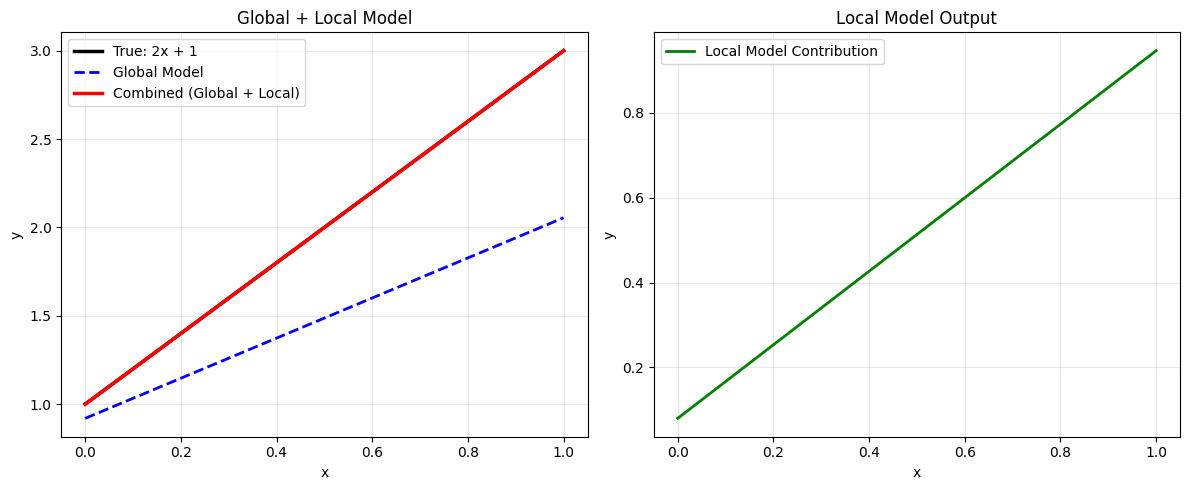

Final Results:
Loss = 0.000000
Global weight = 1.1350, bias = 0.9196
Local  weight = 0.8650, bias = 0.0804
Combined weight = 2.0000
Combined bias   = 1.0000


In [2]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Data
x = torch.linspace(0, 1, 100).view(-1, 1)
y = 2.0 * x + 1.0

# Models
global_model = nn.Linear(1, 1)
local_model = nn.Linear(1, 1)

optimizer = torch.optim.SGD(
    list(global_model.parameters()) + list(local_model.parameters()),
    lr=0.05
)

# Training
for epoch in range(1000):
    optimizer.zero_grad()
    y_pred = global_model(x) + local_model(x)
    loss = torch.mean((y_pred - y)**2)
    loss.backward()
    optimizer.step()

# ====================== PLOTTING ======================
with torch.no_grad():
    global_pred = global_model(x)
    local_pred = local_model(x)
    combined_pred = global_pred + local_pred

# Convert to numpy
x_np = x.squeeze().numpy()
y_np = y.squeeze().numpy()
global_np = global_pred.squeeze().numpy()
local_np = local_pred.squeeze().numpy()
combined_np = combined_pred.squeeze().numpy()

plt.figure(figsize=(12, 5))

# Plot 1: Full results
plt.subplot(1, 2, 1)
plt.plot(x_np, y_np, 'k-', linewidth=2.5, label='True: 2x + 1')
plt.plot(x_np, global_np, 'b--', linewidth=2, label='Global Model')
plt.plot(x_np, combined_np, 'r-', linewidth=2.5, label='Combined (Global + Local)')
plt.title('Global + Local Model')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Local contribution
plt.subplot(1, 2, 2)
plt.plot(x_np, local_np, 'g-', linewidth=2, label='Local Model Contribution')
plt.title('Local Model Output')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print results
print("Final Results:")
print(f"Loss = {loss.item():.6f}")
print(f"Global weight = {global_model.weight.item():.4f}, bias = {global_model.bias.item():.4f}")
print(f"Local  weight = {local_model.weight.item():.4f}, bias = {local_model.bias.item():.4f}")
print(f"Combined weight = {global_model.weight.item() + local_model.weight.item():.4f}")
print(f"Combined bias   = {global_model.bias.item() + local_model.bias.item():.4f}")

#### This is a modification of the above code where we are mapping sin(\pi x)

In [ ]:
import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt

# no. of epochs
N = 15000
gd = 2
ld = 1

# Data
x = torch.linspace(0, 1, 300).view(-1, 1)
y = torch.sin(math.pi * x)

# ==================== MODEL DEFINITION ====================
class SimpleMLP(nn.Module):
    def __init__(self, hidden_dim=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)

# ====================== TRAIN ONLY GLOBAL ======================
print("Training Global-Only Model...")
global_only = SimpleMLP(hidden_dim=gd)

optimizer_global = torch.optim.Adam(global_only.parameters(), lr=0.005)

for epoch in range(N):
    optimizer_global.zero_grad()
    pred = global_only(x)
    loss = torch.mean((pred - y)**2)
    loss.backward()
    optimizer_global.step()

    if epoch % 3000 == 0:
        print(f"Global-Only | Epoch {epoch:5d} | Loss: {loss.item():.6f}")

# ====================== TRAIN GLOBAL + LOCAL ======================
print("\nTraining Global + Local Model...")
global_model = SimpleMLP(hidden_dim=gd)
local_model  = SimpleMLP(hidden_dim=ld)

local_mask = ((x >= 0.25) & (x <= 0.5)).float()

optimizer_both = torch.optim.Adam(
    list(global_model.parameters()) + list(local_model.parameters()),
    lr=0.005
)

for epoch in range(N):
    optimizer_both.zero_grad()

    global_pred = global_model(x)
    local_pred = local_model(x)
    combined_pred = global_pred + local_pred * local_mask

    loss = torch.mean((combined_pred - y)**2)
    loss.backward()
    optimizer_both.step()

    if epoch % 3000 == 0:
        print(f"Global+Local | Epoch {epoch:5d} | Loss: {loss.item():.6f}")

# ====================== PLOTTING ======================
with torch.no_grad():
    global_only_pred = global_only(x)
    global_pred = global_model(x)
    combined_pred = global_pred + local_model(x) * local_mask

x_np = x.squeeze().numpy()
y_np = y.squeeze().numpy()

plt.figure(figsize=(12, 8))

plt.plot(x_np, y_np, 'k-', linewidth=2.8, label='True: sin(πx)')

plt.plot(x_np, global_only_pred.squeeze().numpy(), 'b--', linewidth=2,
         label='Global Only (16 hidden)')

plt.plot(x_np, global_pred.squeeze().numpy(), 'c--', linewidth=2,
         label='Global (from Global+Local)')

plt.plot(x_np, combined_pred.squeeze().numpy(), 'r-', linewidth=2.5,
         label='Global + Local')

plt.axvspan(0.25, 0.5, alpha=0.18, color='orange', label='Local Region [0.25, 0.5]')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparison: Global Only vs Global + Local')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Final Results
print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(f"Global Only Loss      : {torch.mean((global_only_pred - y)**2).item():.6f}")
print(f"Global + Local Loss   : {torch.mean((combined_pred - y)**2).item():.6f}")

Training Global-Only Model...
Global-Only | Epoch     0 | Loss: 0.098163
Global-Only | Epoch  3000 | Loss: 0.095753
Global-Only | Epoch  6000 | Loss: 0.095753
Global-Only | Epoch  9000 | Loss: 0.095753
Global-Only | Epoch 12000 | Loss: 0.095753


In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import math
from ipywidgets import interact
import ipywidgets as widgets
from IPython.display import clear_output

class ControllableMLP(nn.Module):
    def __init__(self, hidden_dim=6):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.layer1 = nn.Linear(1, hidden_dim)
        self.layer2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        return self.layer2(torch.relu(self.layer1(x)))

# ========================== SETUP ==========================
hidden_dim = 2   # ← Change this (recommended: 4~6)

model = ControllableMLP(hidden_dim=hidden_dim)
x = torch.linspace(0, 1, 400).view(-1, 1)
true_y = torch.sin(math.pi * x)

# ========================== SLIDERS ==========================
sliders = {}

# Layer 1 weights and biases
for i in range(hidden_dim):
    sliders[f'w1_{i}'] = widgets.FloatSlider(min=-10, max=10, step=0.05, value=0.0, description=f'w1[{i}]:', continuous_update=True)
    sliders[f'b1_{i}'] = widgets.FloatSlider(min=-10, max=10, step=0.05, value=0.0, description=f'b1[{i}]:', continuous_update=True)

# Layer 2 weights and bias
for i in range(hidden_dim):
    sliders[f'w2_{i}'] = widgets.FloatSlider(min=-10, max=10, step=0.05, value=0.0, description=f'w2[{i}]:', continuous_update=True)

sliders['b2'] = widgets.FloatSlider(min=-10, max=10, step=0.05, value=0.0, description='b2:', continuous_update=True)

# ========================== INTERACTIVE FUNCTION ==========================
def update_plot(**params):
    clear_output(wait=True)   # This fixes multiple plot issue

    # Update model parameters
    with torch.no_grad():
        # Layer 1
        w1 = torch.tensor([[params[f'w1_{i}']] for i in range(hidden_dim)], dtype=torch.float32)
        b1 = torch.tensor([params[f'b1_{i}'] for i in range(hidden_dim)], dtype=torch.float32)
        model.layer1.weight.data = w1
        model.layer1.bias.data = b1

        # Layer 2
        w2 = torch.tensor([[params[f'w2_{i}'] for i in range(hidden_dim)]], dtype=torch.float32)
        b2 = torch.tensor([params['b2']], dtype=torch.float32)
        model.layer2.weight.data = w2
        model.layer2.bias.data = b2

    y_pred = model(x)

    plt.figure(figsize=(10, 6))
    plt.plot(x.numpy(), true_y.numpy(), 'k-', linewidth=2.5, label='True: sin(πx)')
    plt.plot(x.numpy(), y_pred.detach().numpy(), 'r-', linewidth=2.5, label=f'MLP (hidden_dim={hidden_dim})')
    plt.axvspan(0.25, 0.5, alpha=0.15, color='orange')
    plt.title('Real-time Controllable MLP')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Launch interactive widget
interact(update_plot, **sliders);

interactive(children=(FloatSlider(value=0.0, description='w1[0]:', max=10.0, min=-10.0, step=0.05), FloatSlide…